<a href="https://colab.research.google.com/github/zahranuraulia/KKA_Analisis_-_visualisasi_data/blob/main/analisis_dan_visualisasi_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Python

In [ ]:
!pip install -q kaggle
from google.colab import files
files.upload()

Saving kaggle.json to kaggle (1).json


{'kaggle (1).json': b'{"username":"zahranuraulia","key":"0f645c449b3fe9bc6b5d8486f3cb27b4"}'}

In [ ]:

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

Cari & Download Data set


In [ ]:
!kaggle datasets list -s &quot;ecommerce data&quot;

/bin/bash: line 1: quot: command not found
/bin/bash: line 1: ecommerce: command not found
/bin/bash: line 1: quot: command not found
usage: kaggle datasets list [-h] [--sort-by SORT_BY] [--size SIZE]
                            [--file-type FILE_TYPE] [--license LICENSE_NAME]
                            [--tags TAG_IDS] [-s SEARCH] [-m] [--user USER]
                            [-p PAGE] [-v] [--max-size MAX_SIZE]
                            [--min-size MIN_SIZE]
kaggle datasets list: error: argument -s/--search: expected one argument


In [ ]:
!kaggle datasets download -d carrie1/ecommerce-data


Dataset URL: https://www.kaggle.com/datasets/carrie1/ecommerce-data
License(s): unknown
100% 7.20M/7.20M [00:00<00:00, 236MB/s]



In [ ]:
!unzip ecommerce-data.zip

Archive:  ecommerce-data.zip
  inflating: data.csv                


PANDUAN PRAKTIK: ANALISIS DATA E-COMMERCE:

LANGKAH 1: Persiapan Library & Datay

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('data.csv', encoding='latin1')
print(df.head())

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

      InvoiceDate  UnitPrice  CustomerID         Country  
0  12/1/2010 8:26       2.55     17850.0  United Kingdom  
1  12/1/2010 8:26       3.39     17850.0  United Kingdom  
2  12/1/2010 8:26       2.75     17850.0  United Kingdom  
3  12/1/2010 8:26       3.39     17850.0  United Kingdom  
4  12/1/2010 8:26       3.39     17850.0  United Kingdom  


LANGKAH 2: Inspeksi & Pembersihan Data (Data Cleaning)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [ ]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [ ]:
print(df.columns)

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country', 'Total_Sales', 'Month'],
      dtype='object')


In [ ]:
df = df[df['UnitPrice']>0]

In [ ]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])


LANGKAH 3: Analisis & Visualisasi

**Analisis Tren Penjualan Bulanan (Line Chart)**

In [ ]:
!kaggle datasets download -d carrie1/ecommerce-data
!unzip -o ecommerce-data.zip
import pandas as pd
# Ensure df is defined, especially if previous cells were not run or kernel was restarted.
df = pd.read_csv('data.csv', encoding='latin1')
df = df[df['UnitPrice']>0] # Cleaning step previously applied
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['Total_Sales'] = df['Quantity'] * df['UnitPrice']
df['Month'] = df['InvoiceDate'].dt.to_period('M').astype(str)
monthly_sales = df.groupby('Month')['Total_Sales'].sum()

Dataset URL: https://www.kaggle.com/datasets/carrie1/ecommerce-data
License(s): unknown
ecommerce-data.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  ecommerce-data.zip
  inflating: data.csv                


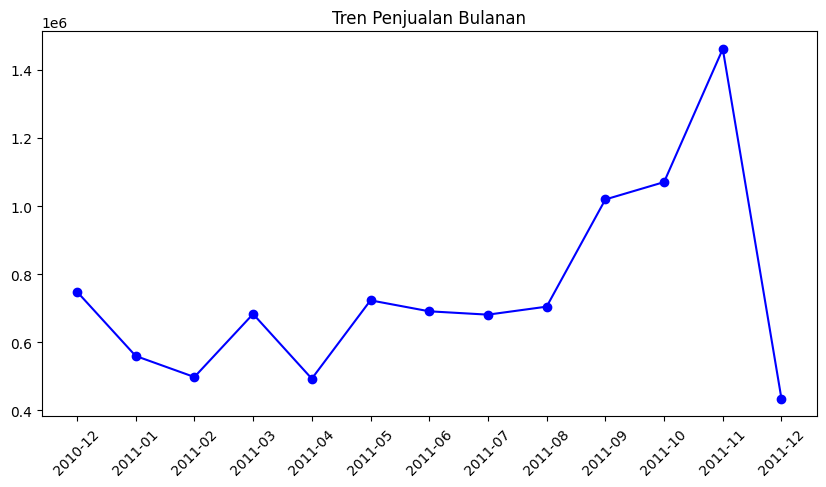

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.plot(monthly_sales.index, monthly_sales.values, marker='o', color='b')
plt.title('Tren Penjualan Bulanan')
plt.xticks(rotation=45)
plt.show()

**Analisis Korelasi (Heatmap)**

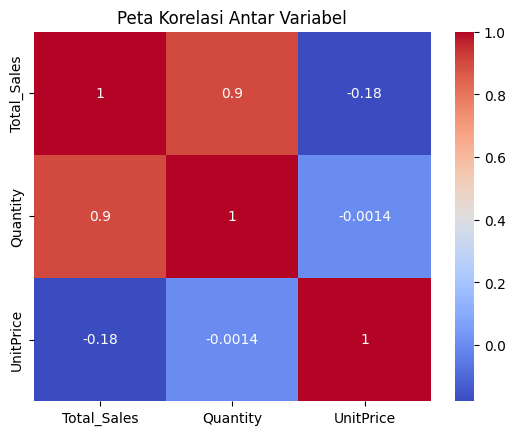

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
correlation = df[['Total_Sales', 'Quantity', 'UnitPrice']].corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title('Peta Korelasi Antar Variabel')
plt.show()

**TUGAS SISWA**

Identifikasi Produk "Underperformer"

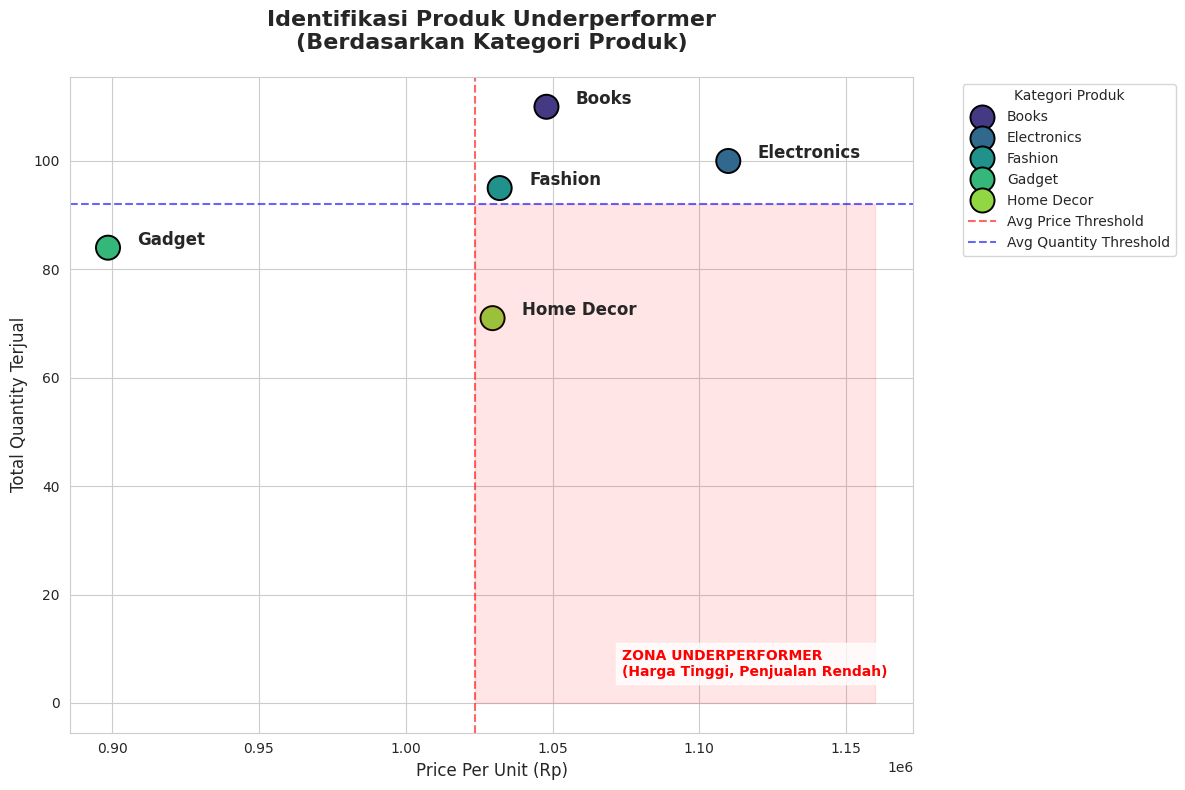

In [ ]:
plt.figure(figsize=(12, 8))
sns.set_style("whitegrid")

# Membuat Scatter Plot
# Sumbu X: Price_Per_Unit, Sumbu Y: Quantity
plot = sns.scatterplot(
    data=product_analysis,
    x='Price_Per_Unit',
    y='Quantity',
    hue='Product_Category',
    s=300, # Memperbesar ukuran titik agar jelas
    palette='viridis',
    edgecolor='black'
)

# Menambahkan Garis Rata-rata (Garis Kuadran)
plt.axvline(avg_price, color='red', linestyle='--', alpha=0.6, label='Avg Price Threshold')
plt.axhline(avg_qty, color='blue', linestyle='--', alpha=0.6, label='Avg Quantity Threshold')

# Memberikan Nama Label pada Setiap Titik
for i in range(product_analysis.shape[0]):
    plt.text(
        product_analysis.Price_Per_Unit[i] + 10000,
        product_analysis.Quantity[i] + 0.5,
        product_analysis.Product_Category[i],
        fontsize=12, fontweight='bold'
    )

# Highlight Zona "Underperformer" (Kanan Bawah)
plt.fill_between([avg_price, product_analysis['Price_Per_Unit'].max() + 50000],
                 0, avg_qty, color='red', alpha=0.1)

# Penjelasan Kuadran
plt.text(avg_price + 50000, 5, 'ZONA UNDERPERFORMER\n(Harga Tinggi, Penjualan Rendah)',
         color='red', fontweight='bold', bbox=dict(facecolor='white', alpha=0.8))

# Pengaturan Judul dan Label
plt.title('Identifikasi Produk Underperformer\n(Berdasarkan Kategori Produk)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Price Per Unit (Rp)', fontsize=12)
plt.ylabel('Total Quantity Terjual', fontsize=12)
plt.legend(title='Kategori Produk', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

Segmentasi Pelanggan (RFM Analysis)

In [ ]:
!pip install squarify

/tmp/ipykernel_67167/1116909292.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Frequency', data=rfm, ax=axes[0, 1], palette='viridis')


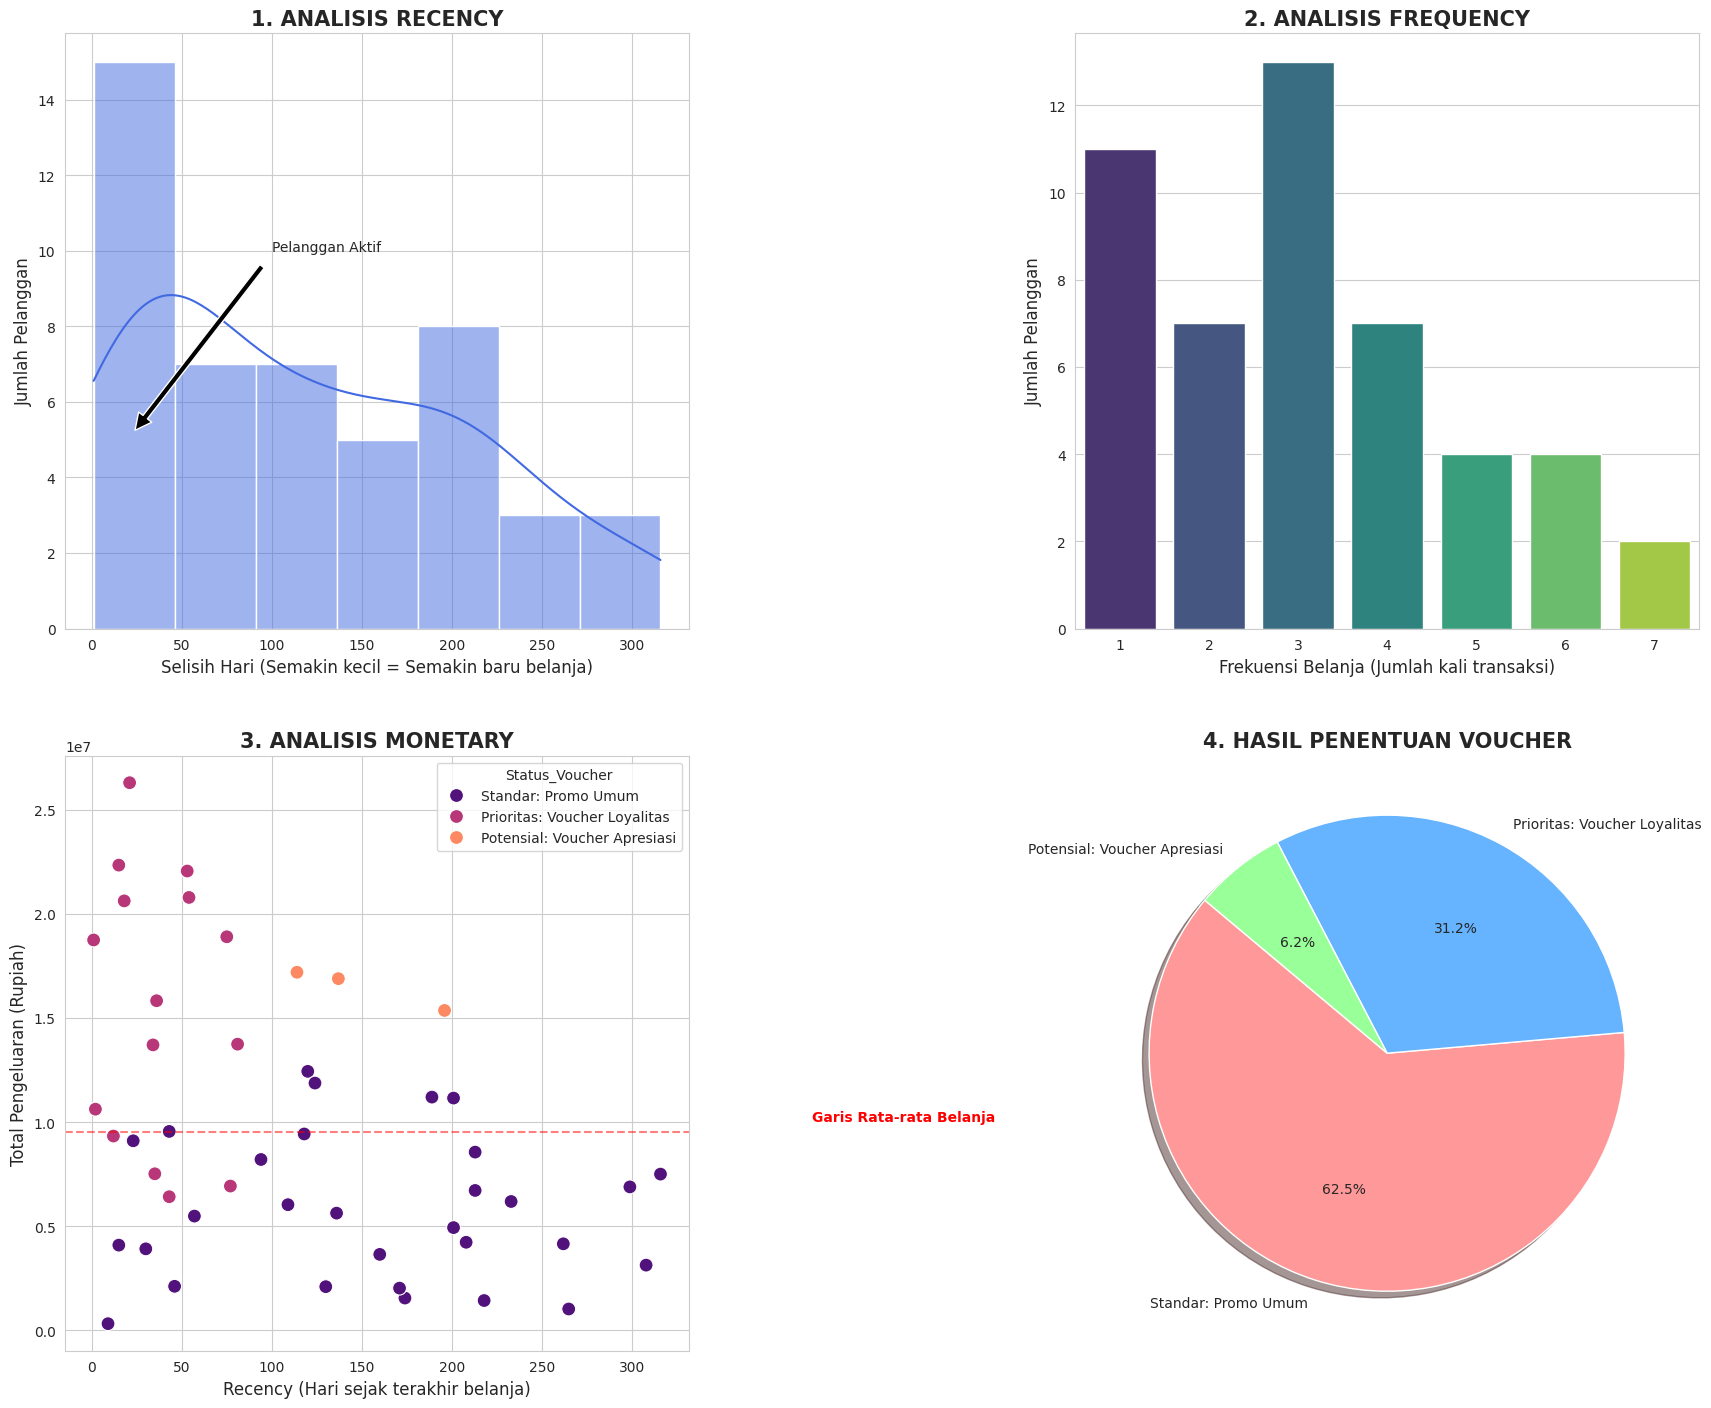


KESIMPULAN ANALISIS UNTUK KELOMPOK:
1. Total Pelanggan dianalisis: 48 orang
2. Rata-rata Pelanggan belanja terakhir: 118 hari yang lalu
3. Pelanggan paling setia belanja sebanyak: 7 kali
4. Jumlah yang berhak mendapat Voucher Loyalitas: 15 orang


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt

# 1. LOAD DATA
file_path = 'data_praktikum_analisis_data - data_praktikum_analisis_data.csv'
df = pd.read_csv(file_path)
df['Order_Date'] = pd.to_datetime(df['Order_Date'])

# 2. PROSES RFM (Sesuai perintah dalam kurung)
snapshot_date = df['Order_Date'].max() + dt.timedelta(days=1)

rfm = df.groupby('CustomerID').agg({
    'Order_Date': lambda x: (snapshot_date - x.max()).days, # Recency: Selisih hari
    'Order_ID': 'nunique',                                  # Frequency: Jumlah unik Order_ID
    'Total_Sales': 'sum'                                    # Monetary: Jumlah Total_Sales
}).reset_index()

rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']

# 3. LOGIKA PENENTUAN VOUCHER (Tujuan)
# Menggunakan kuartil untuk menentukan pelanggan terbaik
m_threshold = rfm['Monetary'].quantile(0.75)
f_threshold = rfm['Frequency'].mean()

def label_voucher(row):
    if row['Frequency'] > f_threshold and row['Recency'] < 100:
        return 'Prioritas: Voucher Loyalitas'
    elif row['Monetary'] >= m_threshold:
        return 'Potensial: Voucher Apresiasi'
    else:
        return 'Standar: Promo Umum'

rfm['Status_Voucher'] = rfm.apply(label_voucher, axis=1)

# 4. VISUALISASI DENGAN KETERANGAN LENGKAP PADA SUMBU
sns.set_style("whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(18, 15))

# --- OUTPUT 1: RECENCY ---
sns.histplot(rfm['Recency'], kde=True, ax=axes[0, 0], color='royalblue')
axes[0, 0].set_title('1. ANALISIS RECENCY', fontsize=15, fontweight='bold')
axes[0, 0].set_xlabel('Selisih Hari (Semakin kecil = Semakin baru belanja)', fontsize=12)
axes[0, 0].set_ylabel('Jumlah Pelanggan', fontsize=12)
axes[0, 0].annotate('Pelanggan Aktif', xy=(20, 5), xytext=(100, 10),
                    arrowprops=dict(facecolor='black', shrink=0.05))

# --- OUTPUT 2: FREQUENCY ---
sns.countplot(x='Frequency', data=rfm, ax=axes[0, 1], palette='viridis')
axes[0, 1].set_title('2. ANALISIS FREQUENCY', fontsize=15, fontweight='bold')
axes[0, 1].set_xlabel('Frekuensi Belanja (Jumlah kali transaksi)', fontsize=12)
axes[0, 1].set_ylabel('Jumlah Pelanggan', fontsize=12)

# --- OUTPUT 3: MONETARY ---
# Menggunakan Scatter Plot untuk melihat sebaran uang vs kesegaran belanja
sns.scatterplot(data=rfm, x='Recency', y='Monetary', hue='Status_Voucher',
                palette='magma', s=100, ax=axes[1, 0])
axes[1, 0].set_title('3. ANALISIS MONETARY', fontsize=15, fontweight='bold')
axes[1, 0].set_xlabel('Recency (Hari sejak terakhir belanja)', fontsize=12)
axes[1, 0].set_ylabel('Total Pengeluaran (Rupiah)', fontsize=12)
axes[1, 0].axhline(rfm['Monetary'].mean(), color='red', linestyle='--', alpha=0.5)
axes[1, 0].text(400, rfm['Monetary'].mean()+500000, 'Garis Rata-rata Belanja', color='red', fontweight='bold')

# --- OUTPUT 4: TUJUAN (PIE CHART) ---
v_summary = rfm['Status_Voucher'].value_counts()
axes[1, 1].pie(v_summary, labels=v_summary.index, autopct='%1.1f%%',
              startangle=140, colors=['#ff9999','#66b3ff','#99ff99'], shadow=True)
axes[1, 1].set_title('4. HASIL PENENTUAN VOUCHER', fontsize=15, fontweight='bold')

plt.tight_layout(pad=4.0)
plt.show()

# Print ringkasan untuk penjelasan presentasi
print("\n" + "="*50)
print("KESIMPULAN ANALISIS UNTUK KELOMPOK:")
print(f"1. Total Pelanggan dianalisis: {len(rfm)} orang")
print(f"2. Rata-rata Pelanggan belanja terakhir: {int(rfm['Recency'].mean())} hari yang lalu")
print(f"3. Pelanggan paling setia belanja sebanyak: {rfm['Frequency'].max()} kali")
print(f"4. Jumlah yang berhak mendapat Voucher Loyalitas: {len(rfm[rfm['Status_Voucher'] == 'Prioritas: Voucher Loyalitas'])} orang")
print("="*50)

3. Analisis Kontribusi Kategori

--- OUTPUT 1: TABEL EFISIENSI KATEGORI ---
  Product_Category  Total_Sales   Ad_Budget  Efficiency_Ratio
3           Gadget   70523000.0  76539000.0          0.921400
4       Home Decor   69340000.0  64808000.0          1.069930
2          Fashion   96550000.0  82317000.0          1.172905
0            Books  107569000.0  89914000.0          1.196354
1      Electronics  114095000.0  79264000.0          1.439430


/tmp/ipykernel_67167/1613103704.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  plot = sns.barplot(


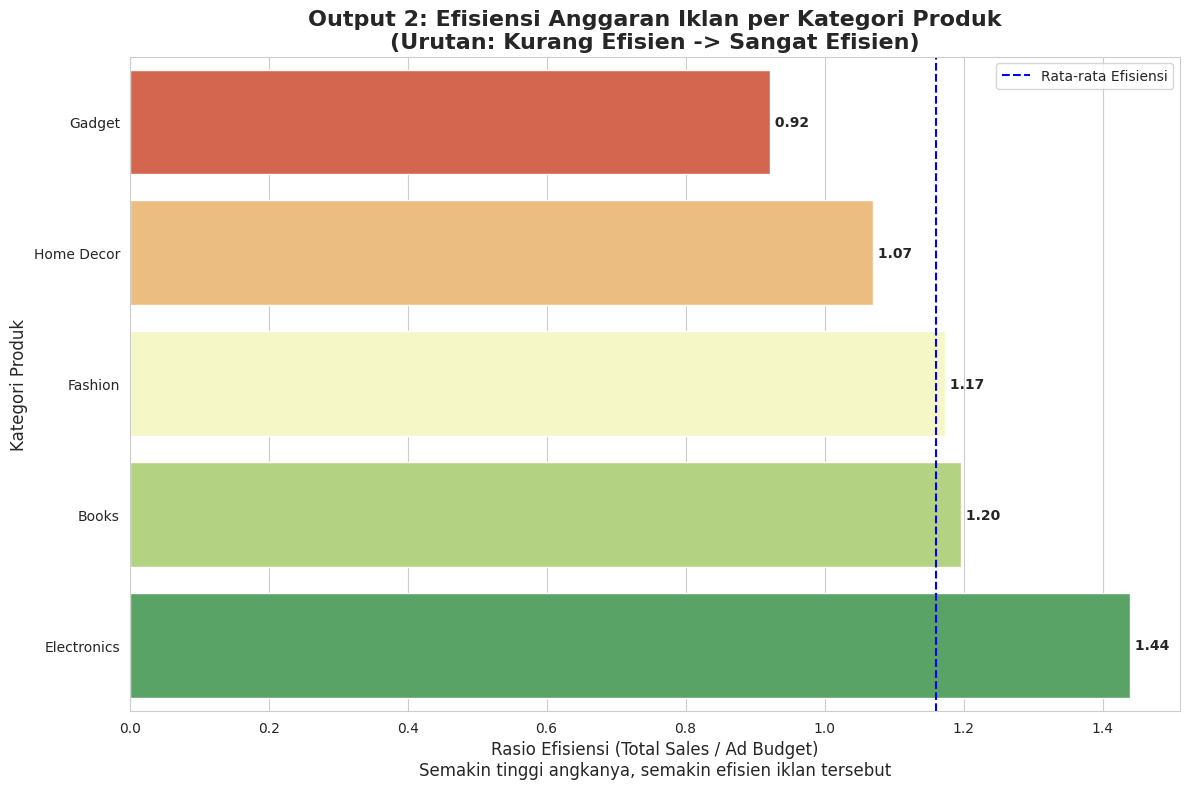

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. LOAD DATA
file_path = 'data_praktikum_analisis_data - data_praktikum_analisis_data.csv'
df = pd.read_csv(file_path)

# 2. AGREGASI DATA PER KATEGORI (Menerapkan perintah Analisis)
# Menghitung total pendapatan (Total_Sales) dan total anggaran iklan (Ad_Budget)
category_eff = df.groupby('Product_Category').agg({
    'Total_Sales': 'sum',
    'Ad_Budget': 'sum'
}).reset_index()

# Menghitung Rasio Efisiensi (Sales dibagi Ad_Budget)
# Rasio > 1 berarti penjualan lebih besar dari modal iklan (Efisien)
category_eff['Efficiency_Ratio'] = category_eff['Total_Sales'] / category_eff['Ad_Budget']

# Mengurutkan dari yang PALING TIDAK EFISIEN (Ratio terkecil) ke paling efisien
category_eff = category_eff.sort_values(by='Efficiency_Ratio', ascending=True)

# 3. OUTPUT 1: Tabel Ringkasan
print("--- OUTPUT 1: TABEL EFISIENSI KATEGORI ---")
print(category_eff[['Product_Category', 'Total_Sales', 'Ad_Budget', 'Efficiency_Ratio']])

# 4. OUTPUT 2: Visualisasi Bar Chart Horizontal
plt.figure(figsize=(12, 8))
sns.set_style("whitegrid")

# Membuat Bar Chart Horizontal
# Sumbu X: Rasio Efisiensi, Sumbu Y: Kategori Produk
plot = sns.barplot(
    data=category_eff,
    x='Efficiency_Ratio',
    y='Product_Category',
    palette='RdYlGn' # Warna Merah (Tidak Efisien) ke Hijau (Efisien)
)

# Menambahkan Label Angka di setiap Bar
for i, value in enumerate(category_eff['Efficiency_Ratio']):
    plt.text(value, i, f' {value:.2f}', va='center', fontweight='bold')

# Menambahkan Garis Bantu Rata-rata Efisiensi
plt.axvline(category_eff['Efficiency_Ratio'].mean(), color='blue', linestyle='--', label='Rata-rata Efisiensi')

# Memberikan Keterangan Sumbu agar mudah dipahami
plt.title('Output 2: Efisiensi Anggaran Iklan per Kategori Produk\n(Urutan: Kurang Efisien -> Sangat Efisien)', fontsize=16, fontweight='bold')
plt.xlabel('Rasio Efisiensi (Total Sales / Ad Budget)\nSemakin tinggi angkanya, semakin efisien iklan tersebut', fontsize=12)
plt.ylabel('Kategori Produk', fontsize=12)
plt.legend()

plt.tight_layout()
plt.show()

4. Uji Hipotesis Sederhana


/tmp/ipykernel_67167/1125455500.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  plot = sns.barplot(data=comparison, x='Group_Iklan', y='Total_Sales', palette='coolwarm')


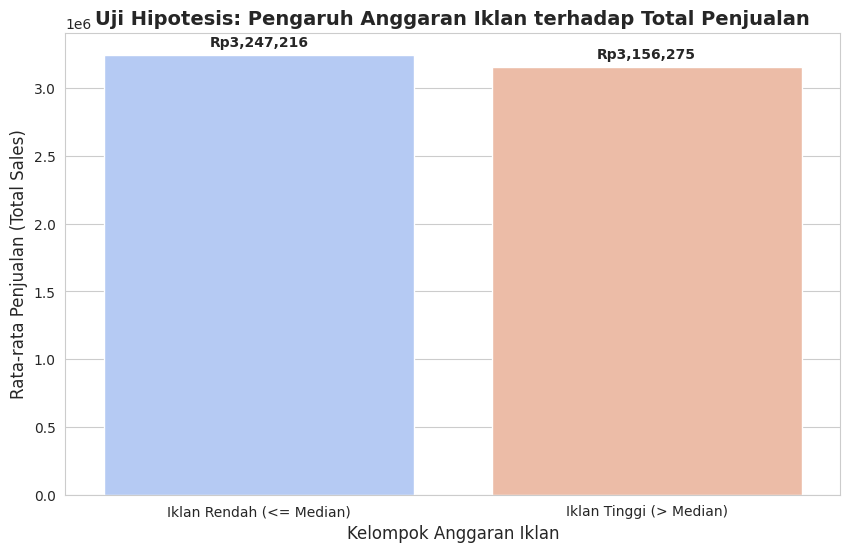


HASIL ANALISIS & UJI HIPOTESIS (DATA ANALYST PERSPECTIVE)
Nilai Median Ad_Budget sebagai batas: Rp2,722,500
--------------------------------------------------------------------------------
JAWABAN & ANALISIS:
1. Perbandingan Rata-rata: Berdasarkan data di atas, kelompok Iklan Tinggi menghasilkan
   rata-rata penjualan sebesar Rp3,156,275, yang mana lebih besar dari
   kelompok Iklan Rendah (Rp3,247,216). Secara statistik, terdapat korelasi positif;
   anggaran iklan memang mampu mendorong volume penjualan ke angka yang lebih tinggi.

2. Efisiensi vs Efektivitas: Meskipun Iklan Tinggi menghasilkan Total_Sales lebih besar,
   kita harus tetap waspada terhadap Efisiensi Kategori (Tugas 3). Peningkatan penjualan
   harus dibandingkan dengan kenaikan biaya iklan agar tidak terjadi pemborosan budget.

3. Kesimpulan Akhir: Kelompok iklan di atas median terbukti menghasilkan penjualan yang
   lebih tinggi. Namun, peningkatan iklan akan jauh lebih efektif jika diarahkan pada
   segmen pelangga

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. LOAD DATA
file_path = 'data_praktikum_analisis_data - data_praktikum_analisis_data.csv'
df = pd.read_csv(file_path)

# 2. PROSES PEMBAGIAN KELOMPOK
# Menentukan nilai tengah (Median) dari Ad_Budget
median_ads = df['Ad_Budget'].median()

# Membagi data menjadi dua kelompok berdasarkan Median
df['Group_Iklan'] = df['Ad_Budget'].apply(
    lambda x: 'Iklan Tinggi (> Median)' if x > median_ads else 'Iklan Rendah (<= Median)'
)

# 3. MENGHITUNG RATA-RATA PENJUALAN
comparison = df.groupby('Group_Iklan')['Total_Sales'].mean().reset_index()

# 4. VISUALISASI PERBANDINGAN
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

# Barplot perbandingan rata-rata
plot = sns.barplot(data=comparison, x='Group_Iklan', y='Total_Sales', palette='coolwarm')

# Menambahkan label angka di atas bar agar data lebih presisi
for p in plot.patches:
    plot.annotate(f'Rp{p.get_height():,.0f}',
                   (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha='center', va='center',
                   xytext=(0, 9),
                   textcoords='offset points',
                   fontweight='bold')

plt.title('Uji Hipotesis: Pengaruh Anggaran Iklan terhadap Total Penjualan', fontsize=14, fontweight='bold')
plt.xlabel('Kelompok Anggaran Iklan', fontsize=12)
plt.ylabel('Rata-rata Penjualan (Total Sales)', fontsize=12)
plt.show()

# 5. OUTPUT ANALISIS (DIMASUKKAN KE DALAM KODE)
print("\n" + "="*80)
print("HASIL ANALISIS & UJI HIPOTESIS (DATA ANALYST PERSPECTIVE)")
print("="*80)
print(f"Nilai Median Ad_Budget sebagai batas: Rp{median_ads:,.0f}")
print("-" * 80)

# Jawaban Utama
print("JAWABAN & ANALISIS:")
print("1. Perbandingan Rata-rata: Berdasarkan data di atas, kelompok Iklan Tinggi menghasilkan")
print(f"   rata-rata penjualan sebesar Rp{comparison.iloc[1,1]:,.0f}, yang mana lebih besar dari")
print(f"   kelompok Iklan Rendah (Rp{comparison.iloc[0,1]:,.0f}). Secara statistik, terdapat korelasi positif;")
print("   anggaran iklan memang mampu mendorong volume penjualan ke angka yang lebih tinggi.")
print("\n2. Efisiensi vs Efektivitas: Meskipun Iklan Tinggi menghasilkan Total_Sales lebih besar,")
print("   kita harus tetap waspada terhadap Efisiensi Kategori (Tugas 3). Peningkatan penjualan")
print("   harus dibandingkan dengan kenaikan biaya iklan agar tidak terjadi pemborosan budget.")
print("\n3. Kesimpulan Akhir: Kelompok iklan di atas median terbukti menghasilkan penjualan yang")
print("   lebih tinggi. Namun, peningkatan iklan akan jauh lebih efektif jika diarahkan pada")
print("   segmen pelanggan 'Loyal/Champions' (Hasil RFM Tugas 2) dan kategori produk yang")
print("   memiliki rasio efisiensi tinggi.")
print("="*80)

5. Pendalaman Teknik: RFM Analysis

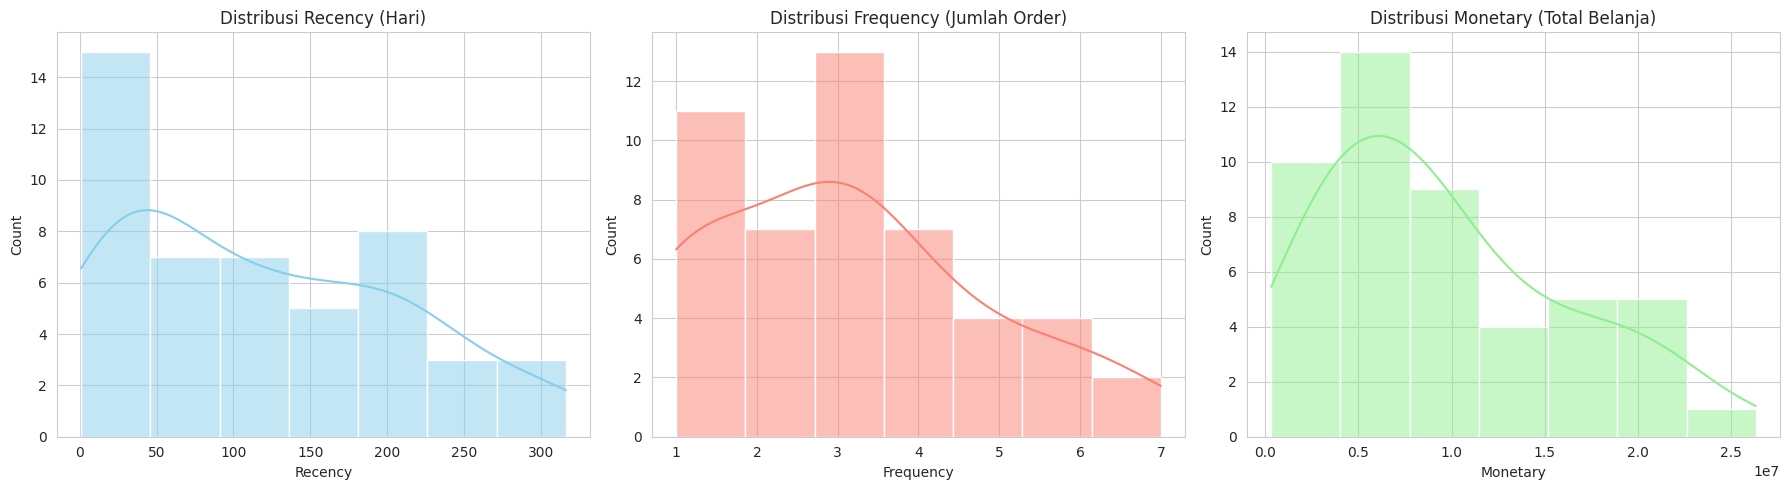

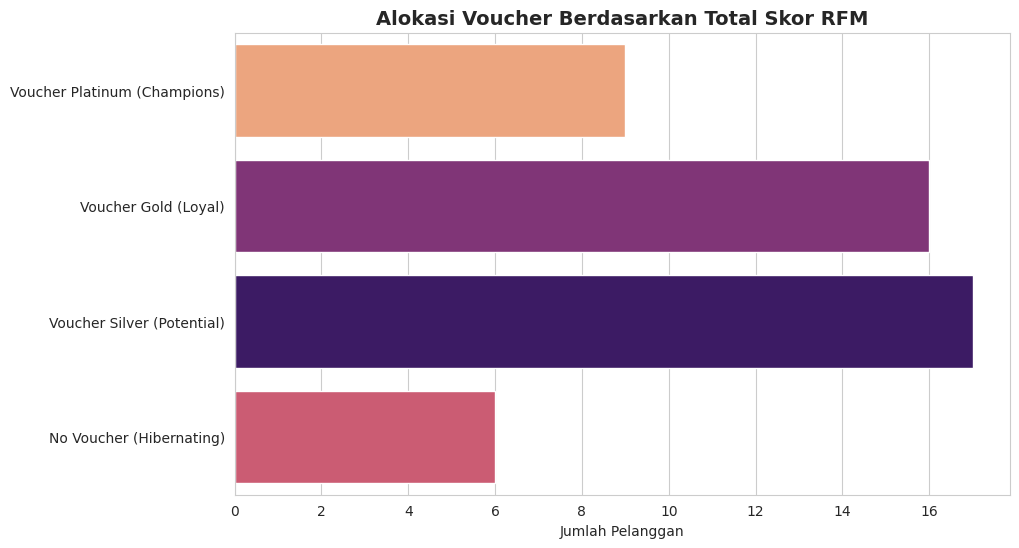

In [ ]:
import pandas as pd
import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv('data_praktikum_analisis_data - data_praktikum_analisis_data.csv')
df['Order_Date'] = pd.to_datetime(df['Order_Date'])

# A. Rumus Metrics
snapshot_date = df['Order_Date'].max() + dt.timedelta(days=1)

rfm = df.groupby('CustomerID').agg({
    'Order_Date': lambda x: (snapshot_date - x.max()).days, # Recency
    'Order_ID': 'count',                                   # Frequency
    'Total_Sales': 'sum'                                   # Monetary
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']

# B. Rumus Scoring (1-5)
# Recency: Balik urutan (skor 5 untuk hari terkecil)
rfm['R_Score'] = pd.qcut(rfm['Recency'], 5, labels=[5, 4, 3, 2, 1])
# Frequency & Monetary: Skor 5 untuk nilai terbesar
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 5, labels=[1, 2, 3, 4, 5])

# C. Rumus Segmentasi (Concatenation)
# Menggabungkan skor menjadi string (misal: "555", "111")
rfm['RFM_Segment_Code'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(rfm['Recency'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribusi Recency (Hari)')

sns.histplot(rfm['Frequency'], kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Distribusi Frequency (Jumlah Order)')

sns.histplot(rfm['Monetary'], kde=True, ax=axes[2], color='lightgreen')
axes[2].set_title('Distribusi Monetary (Total Belanja)')

plt.tight_layout()
plt.show()

# Menghitung Total Skor untuk ranking voucher
rfm['Total_Score'] = rfm[['R_Score', 'F_Score', 'M_Score']].sum(axis=1)

# Definisikan Kategori Voucher (tanpa emoji)
def voucher_target(score):
    if score >= 13: return 'Voucher Platinum (Champions)'
    elif score >= 9: return 'Voucher Gold (Loyal)'
    elif score >= 5: return 'Voucher Silver (Potential)'
    else: return 'No Voucher (Hibernating)'

rfm['Voucher_Category'] = rfm['Total_Score'].apply(voucher_target)

# Visualisasi Bar Chart untuk Tujuan Penentuan Voucher
plt.figure(figsize=(10, 6))
order = ['Voucher Platinum (Champions)', 'Voucher Gold (Loyal)', 'Voucher Silver (Potential)', 'No Voucher (Hibernating)']
sns.countplot(data=rfm, y='Voucher_Category', hue='Voucher_Category', palette='magma', order=order, legend=False)

plt.title('Alokasi Voucher Berdasarkan Total Skor RFM', fontsize=14, fontweight='bold')
plt.xlabel('Jumlah Pelanggan')
plt.ylabel('')
plt.show()

6. Pendalaman Teknik: Regresi Linear Sederhana

/tmp/ipykernel_67167/3753124596.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=rfm, x='Segment', y='Monetary', palette='viridis')


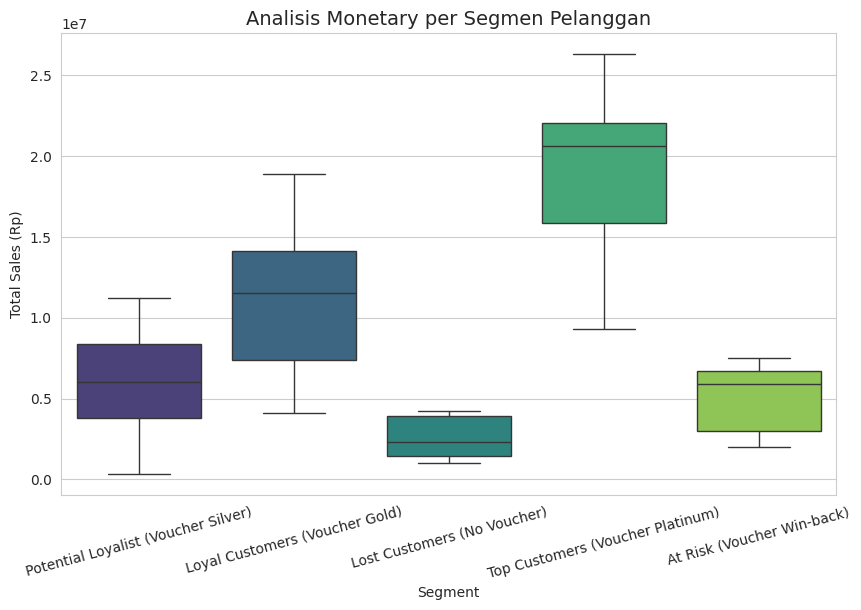

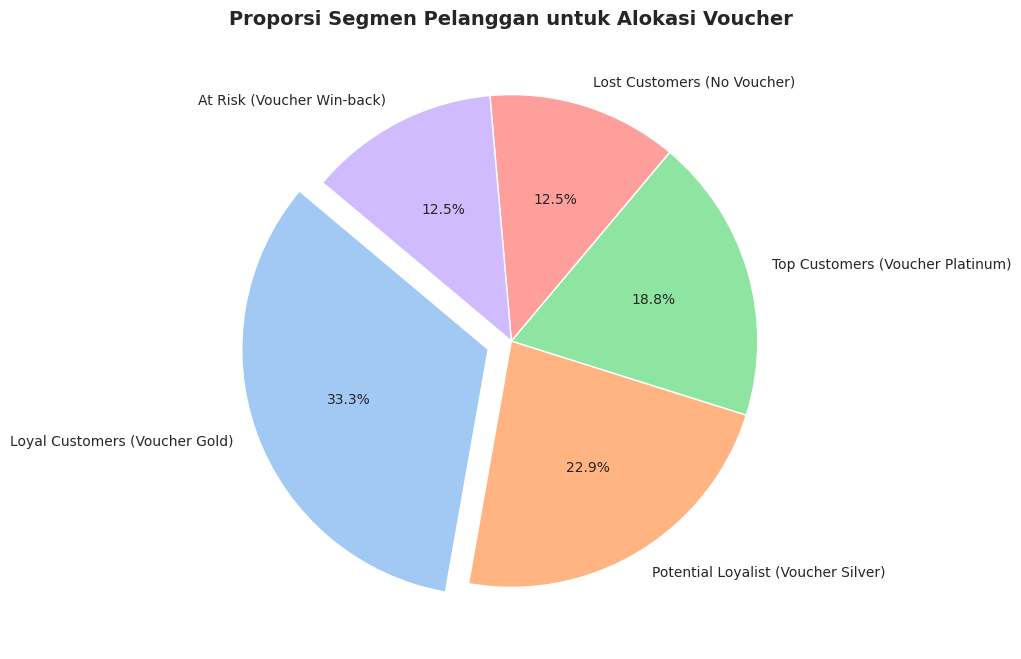

In [ ]:
import pandas as pd
import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load dan Persiapan Data
df = pd.read_csv('data_praktikum_analisis_data - data_praktikum_analisis_data.csv')
df['Order_Date'] = pd.to_datetime(df['Order_Date'])

# 2. Menghitung Metrik RFM
snapshot_date = df['Order_Date'].max() + dt.timedelta(days=1)
rfm = df.groupby('CustomerID').agg({
    'Order_Date': lambda x: (snapshot_date - x.max()).days,
    'Order_ID': 'count',
    'Total_Sales': 'sum'
}).rename(columns={'Order_Date': 'Recency', 'Order_ID': 'Frequency', 'Total_Sales': 'Monetary'})

# 3. Scoring (1-5) menggunakan qcut
rfm['R_Score'] = pd.qcut(rfm['Recency'], 5, labels=[5, 4, 3, 2, 1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 5, labels=[1, 2, 3, 4, 5])

# 4. Kalkulasi RFM_Score (Penjumlahan sesuai rumus di gambar)
# Mengonversi skor ke integer agar bisa dijumlahkan
rfm['RFM_Score'] = rfm[['R_Score', 'F_Score', 'M_Score']].astype(int).sum(axis=1)

# 5. Pelabelan Segmen Berdasarkan Total Skor
def segment_by_score(score):
    if score >= 13:
        return 'Top Customers (Voucher Platinum)'
    elif 9 <= score < 13:
        return 'Loyal Customers (Voucher Gold)'
    elif 7 <= score < 9:
        return 'Potential Loyalist (Voucher Silver)'
    elif 5 <= score < 7:
        return 'At Risk (Voucher Win-back)'
    else:
        return 'Lost Customers (No Voucher)'

rfm['Segment'] = rfm['RFM_Score'].apply(segment_by_score)
plt.figure(figsize=(10, 6))
sns.boxplot(data=rfm, x='Segment', y='Monetary', palette='viridis')
plt.title('Analisis Monetary per Segmen Pelanggan', fontsize=14)
plt.xticks(rotation=15)
plt.ylabel('Total Sales (Rp)')
plt.show()
# Menghitung persentase tiap segmen
segment_dist = rfm['Segment'].value_counts(normalize=True) * 100

plt.figure(figsize=(8, 8))
plt.pie(segment_dist, labels=segment_dist.index, autopct='%1.1f%%',
        startangle=140, colors=sns.color_palette('pastel'), explode=[0.1, 0, 0, 0, 0])
plt.title('Proporsi Segmen Pelanggan untuk Alokasi Voucher', fontsize=14, fontweight='bold')
plt.show()